# Densities

In [1]:
import sys
sys.path.insert(0, '../../src/')

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import tensorflow as tf


from spectrum import channel_spectrum, complex_spacing_ratio, Spectrum, coat_spectrum, spectrum_to_angular, spectrum_to_radial
from analysis import *

#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=4)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-10-27 16:27:16.255826: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 16:27:16.256067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 16:27:16.296426: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 16:27:17.397581: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
def save_spectrum(spectrum, filename):
    csr_array = np.real(spectrum.get_spectrum(is_complex=False))
    np.savetxt(filename, csr_array)

def save_heatmap(heatmap, filename):
    n = heatmap.shape[0]
    grid = np.arange(n)
    x, y = np.meshgrid(grid, grid)

    heatmap = heatmap.flatten()
    x = x.flatten()
    y = y.flatten()

    data = np.array([x, y, heatmap]).T
    np.savetxt(filename, data)
    


In [4]:
r_list = []
a_list = []

## Retrieve CSR

### L = 5

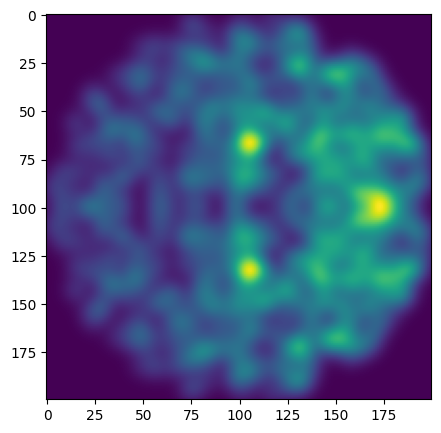

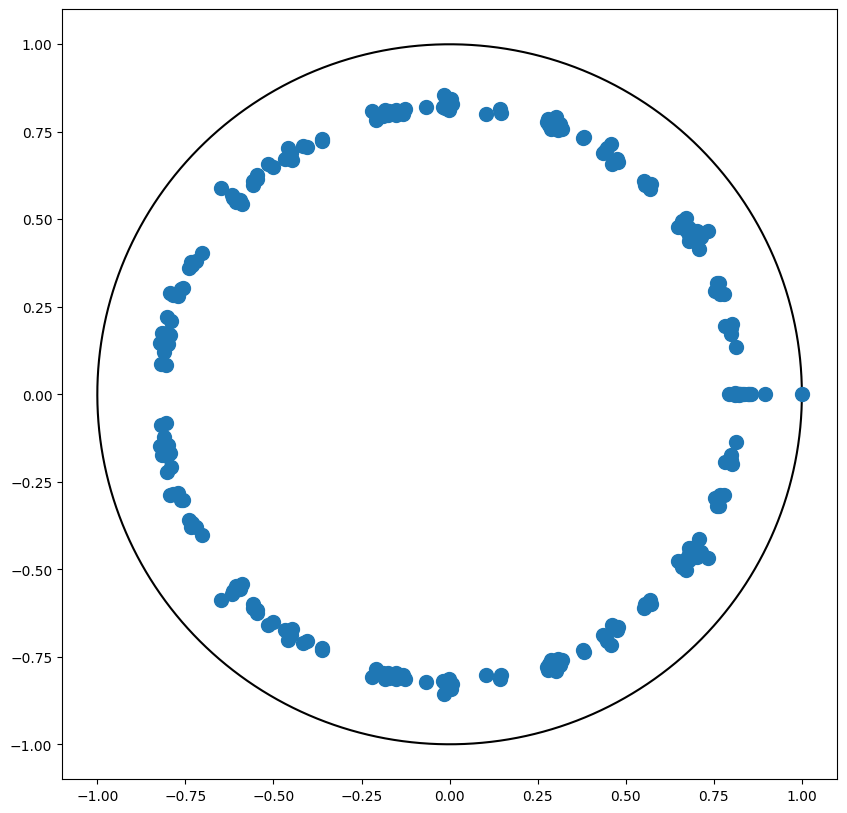

0.652857819355627 -0.23288349901479077


In [5]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()


radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


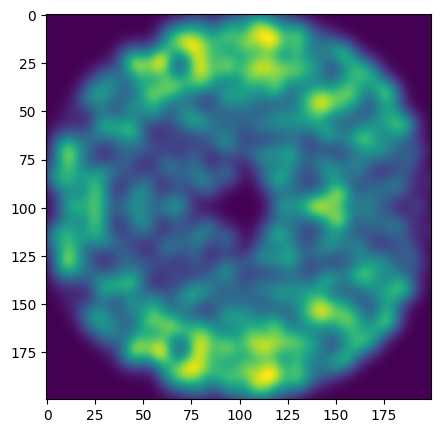

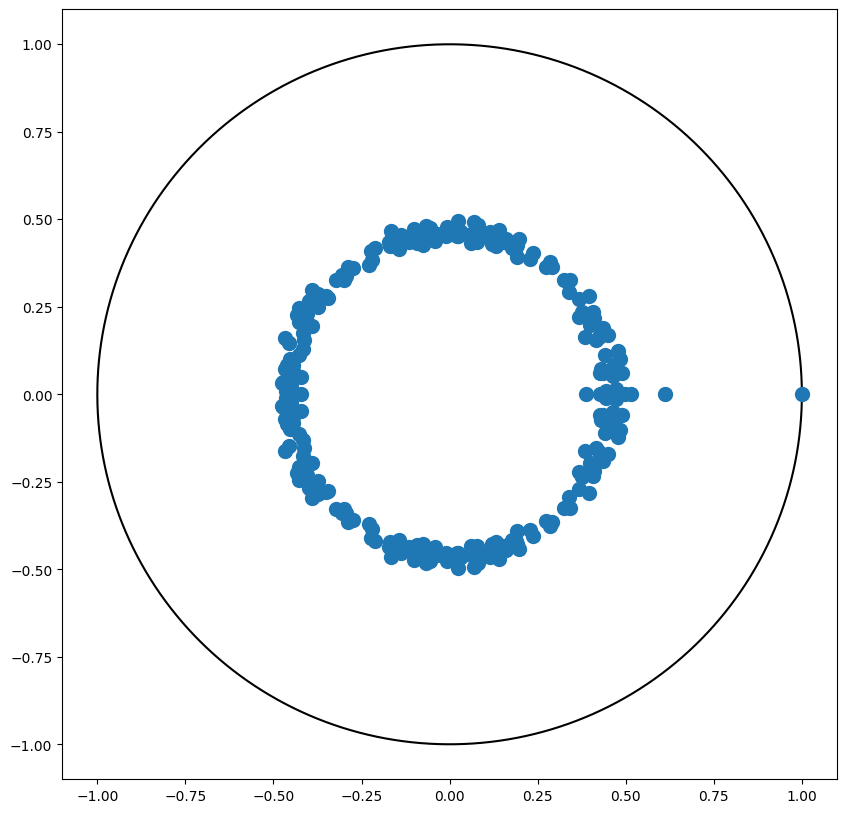

0.7217783109779903 -0.02791625728562684


In [6]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=20.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()


radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)

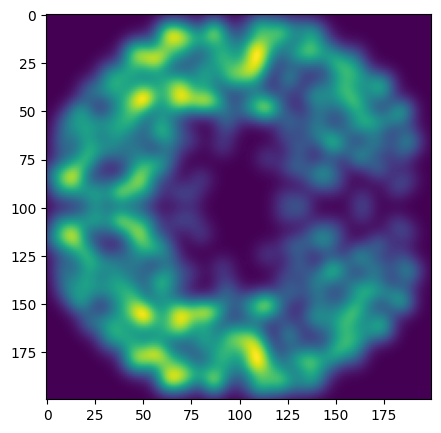

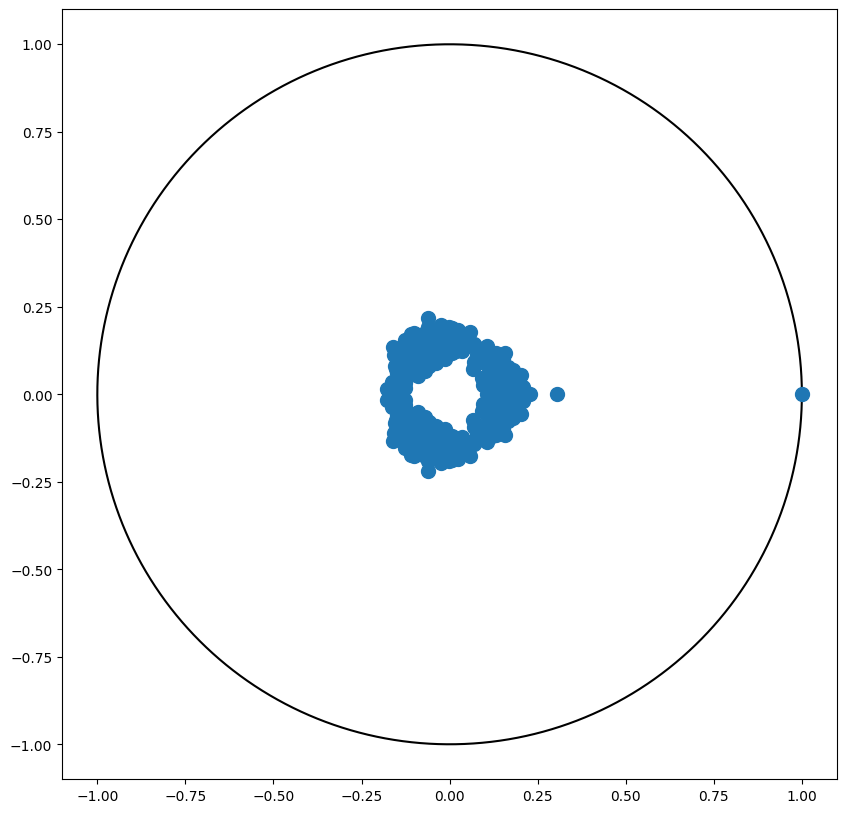

0.7585328549453861 0.12925346792693204


In [ ]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=50.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)

In [8]:
saver([r_list, a_list], "data/integrable_scatter_baseline.pkl")

## Intermediate

In [21]:
r_list = []
a_list = []

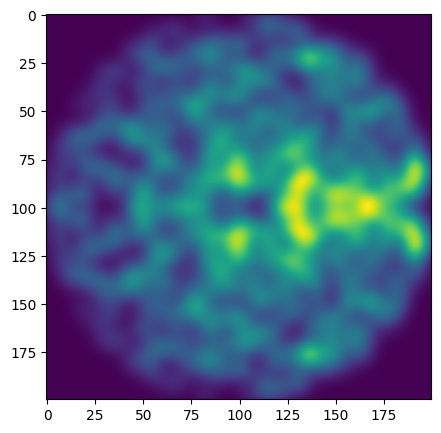

0.6151016041546438 -0.17304799735188392


In [22]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


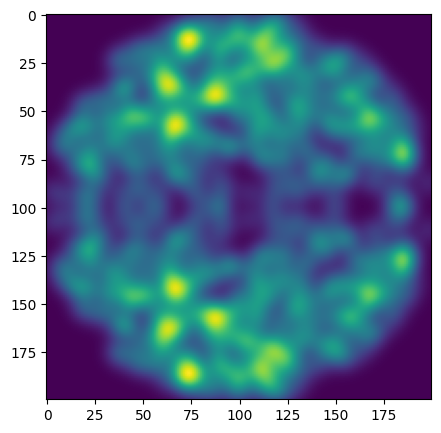

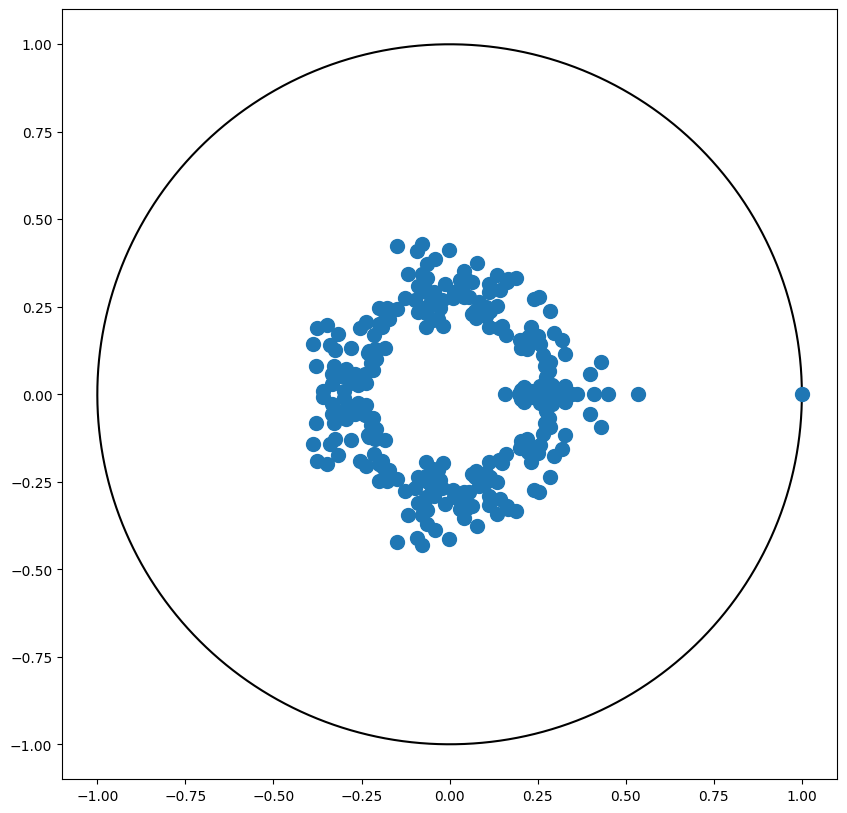

0.7031372033544993 0.02219536376952608


In [23]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=20.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


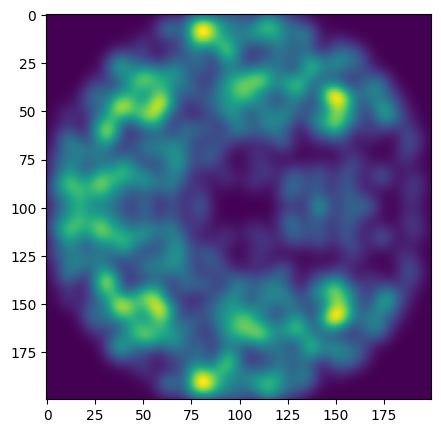

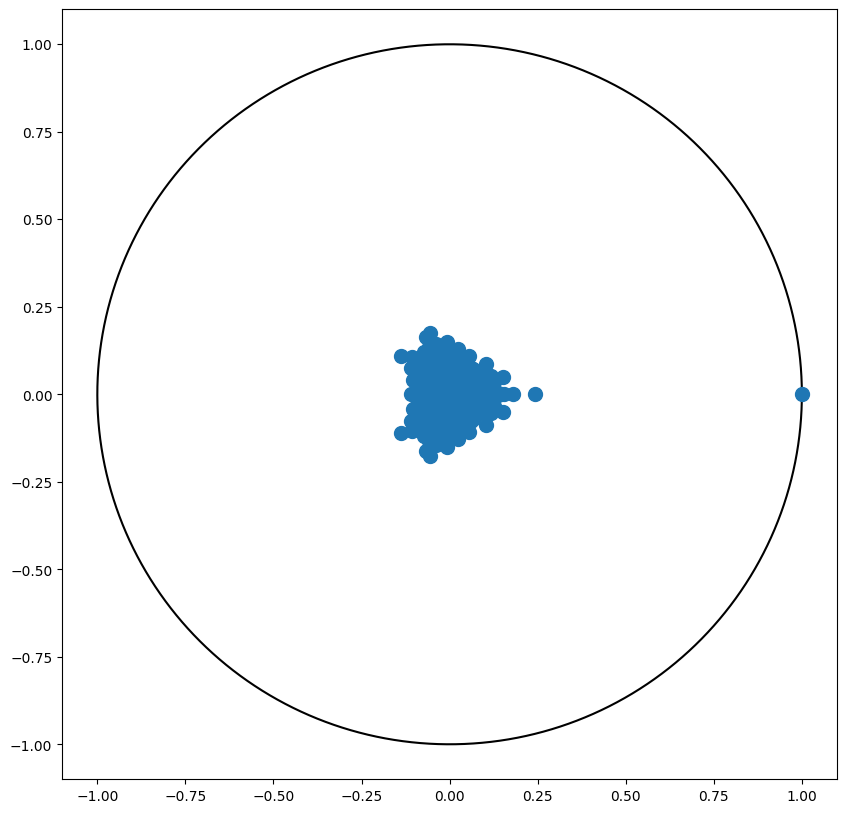

0.7234203267870204 0.13561469725699038


In [24]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=50.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


In [25]:
saver([r_list, a_list], "data/integrable_scatter_intermediate.pkl")